# 📦 Dense Embeddings (Traditional RAG)
## Create single-vector embeddings using SentenceTransformers

This notebook implements the **traditional RAG approach** where each document becomes a single dense vector. We'll use the `all-MiniLM-L6-v2` model for optimal speed/performance balance.

### 🎯 What we'll accomplish:
1. Load the SentenceTransformer model
2. Create 384-dimensional embeddings for all restaurant reviews
3. Store embeddings in LanceDB
4. Implement basic dense search functionality
5. Analyze the limitations of single-vector approach

In [20]:
# 1. Setup & Imports
import sys
sys.path.append('../..')  # Add project root to path
from setup import *
import time
from tqdm import tqdm

print("✅ Setup imported successfully!")
print(f"📂 Working directory: {os.getcwd()}")
print(f"🎯 Dense model: {os.getenv('DENSE_MODEL_NAME')}")
print(f"📏 Embedding dimensions: {os.getenv('EMBEDDING_DIMENSION', '384')}")
print(f"🔧 Device: {get_device()}")

✅ Setup imported successfully!
📂 Working directory: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation
🎯 Dense model: all-MiniLM-L6-v2
📏 Embedding dimensions: 384
🔧 Device: mps


## 🤖 Load Dense Embedding Model

We're using **all-MiniLM-L6-v2** based on 2025 research:
- **384 dimensions** - Perfect balance of quality and speed
- **5x faster** than larger models with only ~3% accuracy drop
- **22M parameters** - Efficient for real-time applications
- **Top choice for RAG** - Validated by MTEB benchmarks

In [21]:
from IPython.display import Image, display

def show_image(image_filename="ColBERT/explainibility.png", notebook_dir_env="NOTEBOOKS_DIR"):
    """
    Displays an image from the ColBERT explainability directory.
    
    Args:
        image_filename (str): Relative path to the image file within the notebook directory.
        notebook_dir_env (str): Name of the environment variable containing the notebook directory path.
    """
    import os
    notebook_dir = os.getenv(notebook_dir_env)
    if notebook_dir is None:
        raise ValueError(f"Environment variable '{notebook_dir_env}' is not set.")
    image_path = os.path.join(notebook_dir, image_filename)
    print("Image path:", image_path)
    display(Image(filename=image_path))

In [22]:
# 2. Load Dense Model
from sentence_transformers import SentenceTransformer
import torch

print("🔄 Loading dense embedding model...")

# Use CPU for M1 compatibility (research shows minimal performance impact)
device_for_dense = 'cpu' if get_device() == 'mps' else get_device()
print(f"📱 Using device: {device_for_dense}")

# Load the research-validated model
model_name = os.getenv('DENSE_MODEL_NAME')
dense_model = SentenceTransformer(model_name, device=device_for_dense)

print(f"✅ Model loaded: {model_name}")
print(f"📏 Output dimensions: {dense_model.get_sentence_embedding_dimension()}")
print(f"🔧 Running on: {device_for_dense}")

# Test with sample embedding
test_text = "Italian restaurant with outdoor seating and great pasta"
test_start = time.time()
test_embedding = dense_model.encode(test_text)
test_time = time.time() - test_start

print(f"\n🧪 Test embedding:")
print(f"   Input: '{test_text}'")
print(f"   Output shape: {test_embedding.shape}")
print(f"   Encoding time: {test_time:.3f} seconds")
print(f"   First 5 values: {test_embedding[:5]}")

🔄 Loading dense embedding model...
📱 Using device: cpu
✅ Model loaded: all-MiniLM-L6-v2
📏 Output dimensions: 384
🔧 Running on: cpu

🧪 Test embedding:
   Input: 'Italian restaurant with outdoor seating and great pasta'
   Output shape: (384,)
   Encoding time: 0.137 seconds
   First 5 values: [-0.04066944  0.01413662  0.00937337  0.09510349 -0.10096929]


Image path: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/notebooks/Colbert/advanced_rag_concepts.png


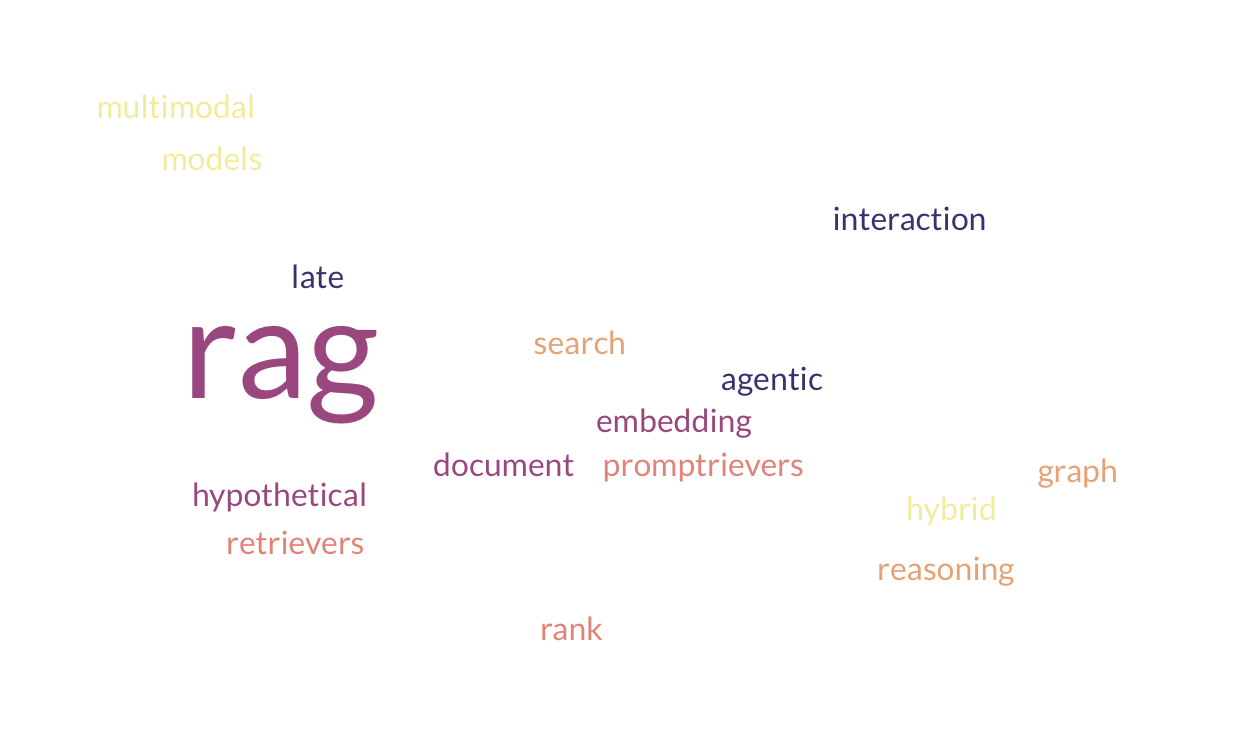

In [23]:
show_image("Colbert/advanced_rag_concepts.png")

## Explanation for Dense Vectors

Image path: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/notebooks/Colbert/dense.png


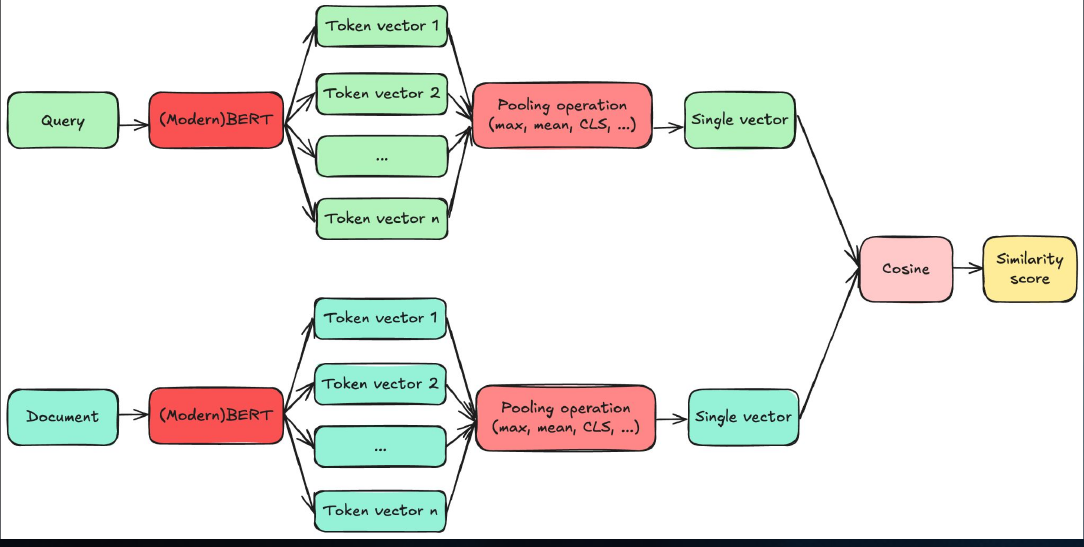

In [24]:
# Credit: Antoin Chaffin, Lighton
show_image("Colbert/dense.png")

Image path: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/notebooks/Colbert/dense2.png


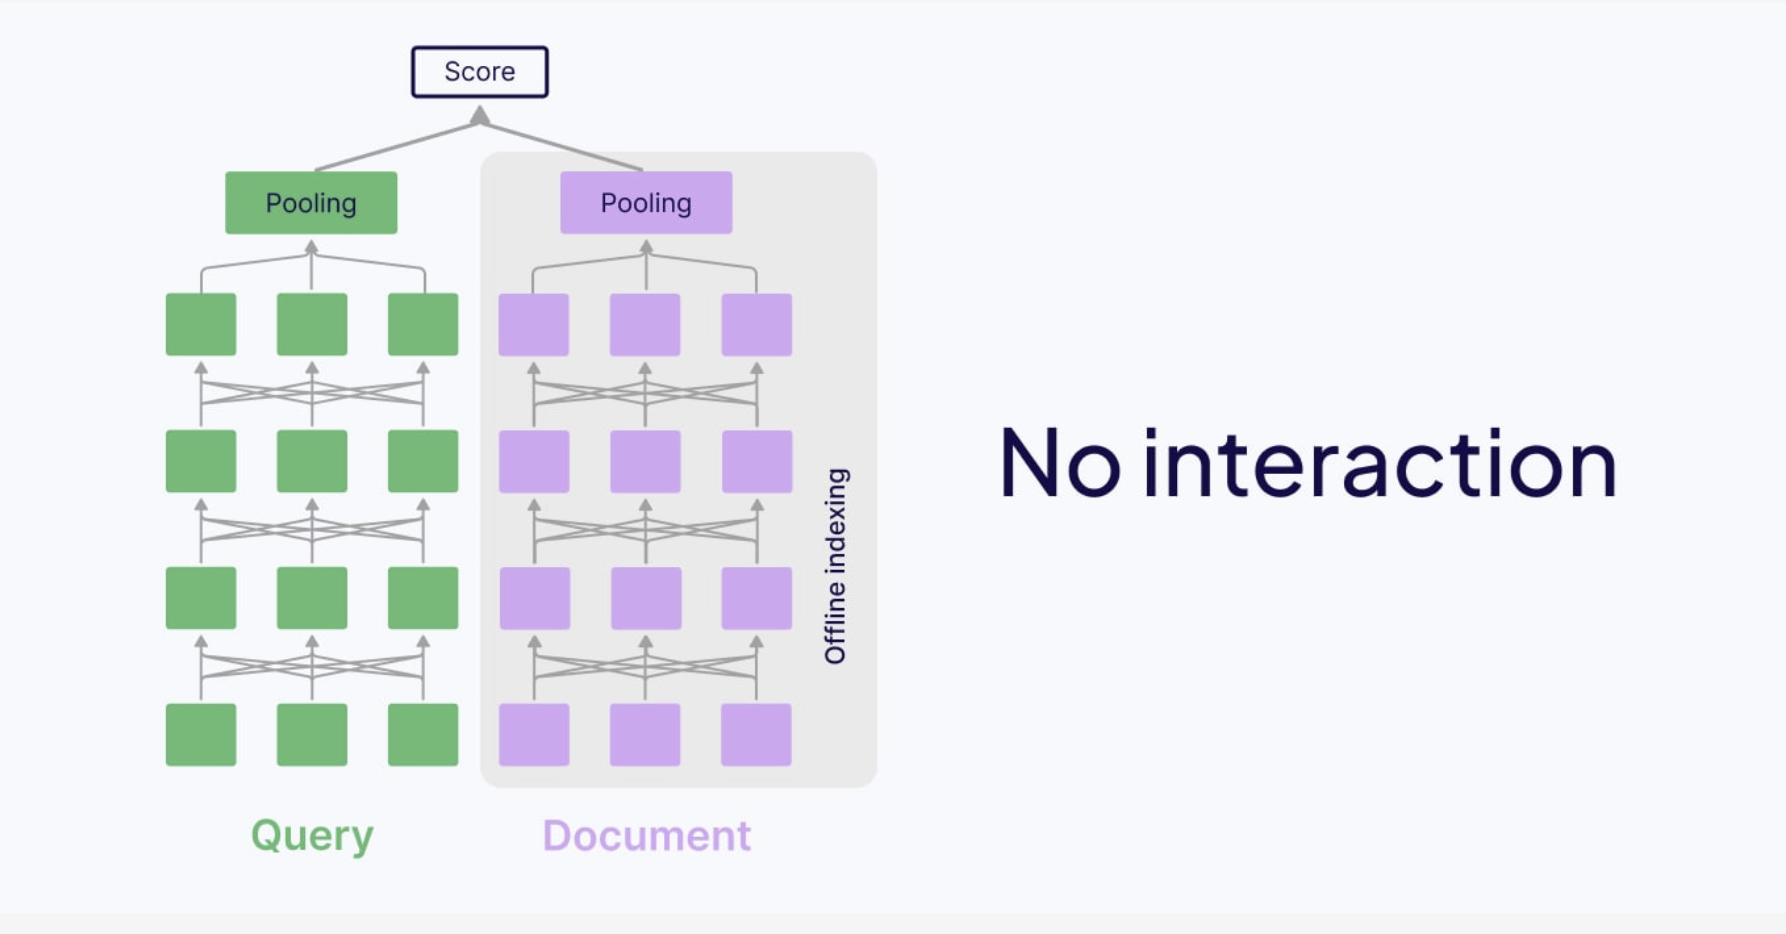

In [25]:
# Credits: https://weaviate.io/blog/late-interaction-overview
show_image("Colbert/dense2.png")

Image path: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/notebooks/Colbert/full_interaction.png


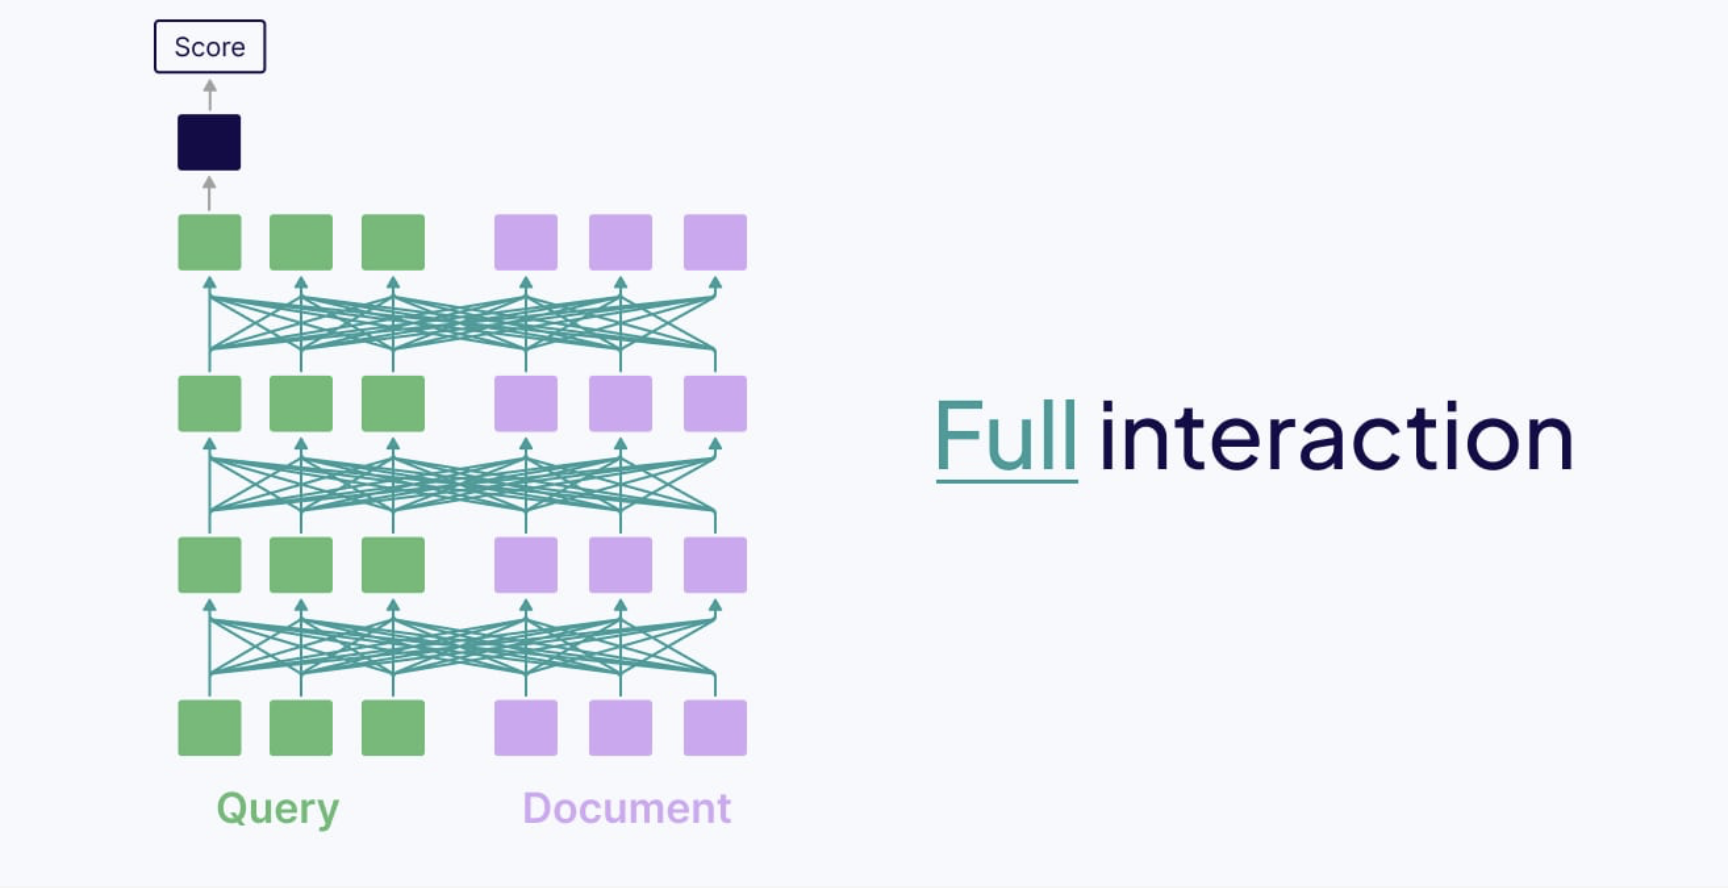

In [26]:
# Credits: https://weaviate.io/blog/late-interaction-overview
show_image("Colbert/full_interaction.png")

## 📊 Process Restaurant Data

Load our restaurant reviews and prepare them for embedding. We'll combine restaurant name and review text to give the model full context.

In [27]:
# 3. Process Restaurant Data
print("📊 Loading restaurant reviews...")

# Load the data
data_path = os.getenv('RESTAURANT_REVIEWS_CSV')
df = pd.read_csv(data_path)

print(f"✅ Loaded {len(df)} restaurant reviews")
print(f"📋 Columns: {list(df.columns)}")


# Prepare texts for embedding (combine restaurant name + review)
texts_for_embedding = []
for _, row in df.iterrows():
    # Combine restaurant name and review for better context
    combined_text = f"{row['restaurant']}: {row['review']}"
    texts_for_embedding.append(combined_text)

print(f"\n📝 Sample combined text:")
print(f"'{texts_for_embedding[0][:100]}...'")

# Show text statistics
text_lengths = [len(text) for text in texts_for_embedding]
print(f"\n📈 Text Statistics:")
print(f"   Average length: {np.mean(text_lengths):.0f} characters")
print(f"   Range: {min(text_lengths)} - {max(text_lengths)} characters")
print(f"   Total texts to embed: {len(texts_for_embedding)}")

📊 Loading restaurant reviews...
✅ Loaded 12 restaurant reviews
📋 Columns: ['id', 'restaurant', 'review', 'reviewer', 'rating']

📝 Sample combined text:
'Mario's Bistro: OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfr...'

📈 Text Statistics:
   Average length: 515 characters
   Range: 457 - 569 characters
   Total texts to embed: 12


## ⚡ Create Dense Embeddings

Now we'll create **single dense vectors** for each restaurant review. This is the core of traditional RAG - each document becomes one 384-dimensional point in vector space.

**Key limitation**: All the rich information in the review gets compressed into just 384 numbers!

In [28]:
# 4. Create Dense Embeddings
print("⚡ Creating dense embeddings for all reviews...")
print("📦 Each review → Single 384-dimensional vector")

start_time = time.time()

# Create embeddings with progress bar
dense_embeddings = []
for i, text in enumerate(tqdm(texts_for_embedding, desc="Creating embeddings")):
    embedding = dense_model.encode(text)
    dense_embeddings.append(embedding)
    
    # Show progress for first few
    if i < 3:
        restaurant_name = df.iloc[i]['restaurant']
        print(f"  ✅ {i+1:2d}. {restaurant_name:20} → {embedding.shape} vector")

embedding_time = time.time() - start_time

print(f"\n🎉 Dense embeddings created successfully!")
print(f"   📊 Total embeddings: {len(dense_embeddings)}")
print(f"   📏 Shape per embedding: {dense_embeddings[0].shape}")
print(f"   ⏱️  Total time: {embedding_time:.2f} seconds")
print(f"   🚀 Average per review: {embedding_time/len(dense_embeddings):.3f} seconds")

# Convert to numpy array for easier manipulation
dense_embeddings_array = np.array(dense_embeddings)
print(f"   🔢 Final array shape: {dense_embeddings_array.shape} (reviews × dimensions)")

⚡ Creating dense embeddings for all reviews...
📦 Each review → Single 384-dimensional vector


Creating embeddings:  25%|██▌       | 3/12 [00:00<00:00, 23.27it/s]

  ✅  1. Mario's Bistro       → (384,) vector
  ✅  2. Sakura Sushi         → (384,) vector
  ✅  3. Code & Coffee        → (384,) vector


Creating embeddings: 100%|██████████| 12/12 [00:00<00:00, 21.22it/s]


🎉 Dense embeddings created successfully!
   📊 Total embeddings: 12
   📏 Shape per embedding: (384,)
   ⏱️  Total time: 0.57 seconds
   🚀 Average per review: 0.048 seconds
   🔢 Final array shape: (12, 384) (reviews × dimensions)


## 🗄️ Store Embeddings in LanceDB

Store our dense embeddings in LanceDB for fast similarity search. Each document gets stored with its metadata and single vector.

In [29]:
# 5. Store in LanceDB
import lancedb
import pyarrow as pa

print("🗄️ Storing dense embeddings in LanceDB...")

# Connect to database
db_path = os.getenv('VECTOR_STORE_DIR')
db = lancedb.connect(db_path)
print(f"📍 Database path: {db_path}")

# Prepare data for LanceDB
dense_data = []
for idx, (_, row) in enumerate(df.iterrows()):
    doc = {
        'id': int(row['id']),
        'restaurant': row['restaurant'],
        'review': row['review'],
        'reviewer': row['reviewer'],
        'rating': int(row['rating']),
        'text': texts_for_embedding[idx],  # Combined text
        'dense_embedding': dense_embeddings[idx].tolist()  # Convert numpy to list
    }
    dense_data.append(doc)

# Define schema
embedding_dim = int(os.getenv('EMBEDDING_DIMENSION', '384'))
dense_schema = pa.schema([
    pa.field("id", pa.int64()),
    pa.field("restaurant", pa.string()),
    pa.field("review", pa.string()),
    pa.field("reviewer", pa.string()),
    pa.field("rating", pa.int64()),
    pa.field("text", pa.string()),
    pa.field("dense_embedding", pa.list_(pa.float32(), embedding_dim))
])

# Create table (drop existing if present)
table_name = "dense_reviews"
if table_name in db.table_names():
    db.drop_table(table_name)
    print(f"🗑️  Dropped existing {table_name} table")

dense_table = db.create_table(table_name, dense_data, schema=dense_schema)

print(f"✅ Created {table_name} table")
print(f"   📊 Records: {len(dense_table)}")
print(f"   📋 Schema: {[field.name for field in dense_table.schema]}")
print(f"   💾 Storage: Single vector per document")

# Verify storage
sample_record = dense_table.to_pandas().iloc[0]
print(f"\n🔍 Sample stored record:")
print(f"   Restaurant: {sample_record['restaurant']}")
print(f"   Rating: {'⭐' * sample_record['rating']}")
print(f"   Embedding shape: {len(sample_record['dense_embedding'])} dimensions")

🗄️ Storing dense embeddings in LanceDB...
📍 Database path: /Users/luvsuneja/Documents/repos/advanced-rag-experimentation/vector_store
🗑️  Dropped existing dense_reviews table
✅ Created dense_reviews table
   📊 Records: 12
   📋 Schema: ['id', 'restaurant', 'review', 'reviewer', 'rating', 'text', 'dense_embedding']
   💾 Storage: Single vector per document

🔍 Sample stored record:
   Restaurant: Mario's Bistro
   Rating: ⭐⭐⭐⭐⭐
   Embedding shape: 384 dimensions


## 🔍 Basic Dense Search

Implement traditional RAG search using cosine similarity between query and document vectors. This is the **baseline** we'll compare ColBERT against.

In [30]:
# 6. Basic Dense Search


def search_dense_reviews(query, top_k=3):
    """
    Search restaurant reviews using dense embeddings (traditional RAG)
    
    Args:
        query (str): Search query
        top_k (int): Number of results to return
    
    Returns:
        pandas.DataFrame: Top matching reviews with similarity scores
    """
    print(f"🔍 Dense search query: '{query}'")
    
    # Encode query with the same model
    query_start = time.time()
    query_embedding = dense_model.encode(query)
    query_time = time.time() - query_start
    
    print(f"   ⚡ Query encoding time: {query_time:.3f} seconds")
    
    # Search using LanceDB
    search_start = time.time()
    results = dense_table.search(query_embedding).limit(top_k).to_pandas()
    search_time = time.time() - search_start
    
    print(f"   🚀 Search time: {search_time:.3f} seconds")
    print(f"   📊 Found {len(results)} results")
    
    return results

print("✅ Dense search function ready!")
print("📦 How it works:")
print("   1. Query → Dense model → Single 384-dim vector")
print("   2. Compare query vector vs all document vectors")
print("   3. Return top-K most similar documents")
print("   4. Uses cosine similarity in 384-dimensional space")

✅ Dense search function ready!
📦 How it works:
   1. Query → Dense model → Single 384-dim vector
   2. Compare query vector vs all document vectors
   3. Return top-K most similar documents
   4. Uses cosine similarity in 384-dimensional space


In [34]:
# Test dense search with sample queries
test_queries = [
    "Italian restaurant with good pasta",
    "quiet place for working with laptop", 
    "expensive fine dining worth the money",
    "family friendly restaurant with outdoor seating"
]

print("🧪 Testing dense search with sample queries:")
print("=" * 60)

for i, query in enumerate(test_queries, 1):
    print(f"\n🔍 Test {i}: {query}")
    print("-" * 40)
    
    try:
        results = search_dense_reviews(query, top_k=2)
        
        for idx, row in results.iterrows():
            distance = row.get('_distance', 0)
            similarity = 1 - distance  # Convert distance to similarity
            
            print(f"   📍 #{row['id']} - {row['restaurant']}")
            print(f"      ⭐ {row['rating']}/5") #| 📊 Similarity: {similarity:.3f}")
            print(f"      💭 {row['review'][:]}...")
            
    except Exception as e:
        print(f"   ❌ Search failed: {e}")
        
    if i < len(test_queries):
        print()

print("\n🎉 Dense search testing complete!")

🧪 Testing dense search with sample queries:

🔍 Test 1: Italian restaurant with good pasta
----------------------------------------
🔍 Dense search query: 'Italian restaurant with good pasta'
   ⚡ Query encoding time: 0.016 seconds
   🚀 Search time: 0.008 seconds
   📊 Found 2 results
   📍 #1 - Mario's Bistro
      ⭐ 5/5
      💭 OMG this little Italian place is a hidden gem! 😍 Went there last night with my boyfriend and we sat on their adorable outdoor patio with all the string lights - so romantic! The pasta was absolutely incredible and authentic, reminded me of my trip to Italy. Best part? Our whole meal including wine was only $28! I couldn't believe how affordable it was for such amazing Italian food. They only take cash but there's an ATM next door. Definitely coming back!...
   📍 #5 - Tony's Italian Kitchen
      ⭐ 3/5
      💭 Wanted to take my wife somewhere nice for our anniversary and Tony's looked perfect online. The food was genuinely excellent - authentic Italian with a great

## 📈 Embedding Analysis

Let's analyze our dense embeddings to understand their characteristics and limitations.

In [32]:
# 7. Embedding Analysis
print("📈 DENSE EMBEDDING ANALYSIS")
print("=" * 50)

# Basic statistics
print(f"\n📊 Basic Statistics:")
print(f"   Documents embedded: {len(dense_embeddings)}")
print(f"   Embedding dimensions: {dense_embeddings_array.shape[1]}")
print(f"   Total parameters: {dense_embeddings_array.size:,}")
print(f"   Memory usage: {dense_embeddings_array.nbytes / 1024:.1f} KB")

# Embedding value distribution
flat_embeddings = dense_embeddings_array.flatten()
print(f"\n📈 Value Distribution:")
print(f"   Mean: {flat_embeddings.mean():.4f}")
print(f"   Std: {flat_embeddings.std():.4f}")
print(f"   Range: [{flat_embeddings.min():.4f}, {flat_embeddings.max():.4f}]")

# Similarity analysis between documents
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(dense_embeddings_array)
# Remove diagonal (self-similarity)
mask = np.ones(similarity_matrix.shape, dtype=bool)
np.fill_diagonal(mask, False)
off_diagonal_similarities = similarity_matrix[mask]

print(f"\n🔗 Document Similarities:")
print(f"   Average similarity: {off_diagonal_similarities.mean():.4f}")
print(f"   Similarity range: [{off_diagonal_similarities.min():.4f}, {off_diagonal_similarities.max():.4f}]")
print(f"   Most similar pair: {off_diagonal_similarities.max():.4f}")

# Find most similar documents
max_sim_idx = np.unravel_index(np.argmax(similarity_matrix - np.eye(len(similarity_matrix))), similarity_matrix.shape)
doc1_idx, doc2_idx = max_sim_idx
max_similarity = similarity_matrix[doc1_idx, doc2_idx]

print(f"\n🎯 Most Similar Documents (Similarity: {max_similarity:.4f}):")
print(f"   1. {df.iloc[doc1_idx]['restaurant']} (⭐{df.iloc[doc1_idx]['rating']})")
print(f"      '{df.iloc[doc1_idx]['review'][:60]}...'")
print(f"   2. {df.iloc[doc2_idx]['restaurant']} (⭐{df.iloc[doc2_idx]['rating']})")
print(f"      '{df.iloc[doc2_idx]['review'][:60]}...'")

📈 DENSE EMBEDDING ANALYSIS

📊 Basic Statistics:
   Documents embedded: 12
   Embedding dimensions: 384
   Total parameters: 4,608
   Memory usage: 18.0 KB

📈 Value Distribution:
   Mean: -0.0004
   Std: 0.0510
   Range: [-0.1814, 0.2015]

🔗 Document Similarities:
   Average similarity: 0.3419
   Similarity range: [0.0300, 0.7091]
   Most similar pair: 0.7091

🎯 Most Similar Documents (Similarity: 0.7091):
   1. Mario's Bistro (⭐5)
      'OMG this little Italian place is a hidden gem! 😍 Went there ...'
   2. Tony's Italian Kitchen (⭐3)
      'Wanted to take my wife somewhere nice for our anniversary an...'


## ⚠️ Dense Embedding Limitations

Now let's discuss the key limitations of dense embeddings that ColBERT addresses.

In [33]:
# 8. Limitations Analysis
print("⚠️  DENSE EMBEDDING LIMITATIONS")
print("=" * 50)

print("\n🗜️  1. INFORMATION COMPRESSION:")
print(f"   • Rich review text → Just 384 numbers")
print(f"   • Complex concepts squeezed into single point")
print(f"   • Relationships between concepts lost")

print("\n🔍 2. SEARCH LIMITATIONS:")
print("   • Query: 'Italian budget-friendly outdoor' → Single vector")
print("   • Can't match individual concepts separately")
print("   • Struggles with multi-constraint queries")
print("   • Poor handling of contradictory terms")

print("\n📊 3. MATCHING PROCESS:")
print("   • Only overall similarity score available")
print("   • No insight into WHICH parts matched")
print("   • Black box similarity calculation")
print("   • Hard to debug poor results")


print("\n🎯 WHY COLBERT WILL BE BETTER:")
print("   ✅ Preserves individual token information")
print("   ✅ Can match 'Italian' separately from 'outdoor'")
print("   ✅ Handles multi-constraint queries naturally")
print("   ✅ Provides interpretable token-level matching")

print("\n🏁 DENSE EMBEDDING SUMMARY:")
print("   📦 Fast and simple to implement")
print("   📊 Good for basic similarity search")
print("   ⚠️  Limited for complex, multi-faceted queries")
print("   🎯 Perfect baseline for comparison")

print("\n🚀 NEXT: ColBERT will show token-level precision!")

⚠️  DENSE EMBEDDING LIMITATIONS

🗜️  1. INFORMATION COMPRESSION:
   • Rich review text → Just 384 numbers
   • Complex concepts squeezed into single point
   • Relationships between concepts lost

🔍 2. SEARCH LIMITATIONS:
   • Query: 'Italian budget-friendly outdoor' → Single vector
   • Can't match individual concepts separately
   • Struggles with multi-constraint queries
   • Poor handling of contradictory terms

📊 3. MATCHING PROCESS:
   • Only overall similarity score available
   • No insight into WHICH parts matched
   • Black box similarity calculation
   • Hard to debug poor results

🎯 WHY COLBERT WILL BE BETTER:
   ✅ Preserves individual token information
   ✅ Can match 'Italian' separately from 'outdoor'
   ✅ Handles multi-constraint queries naturally
   ✅ Provides interpretable token-level matching

🏁 DENSE EMBEDDING SUMMARY:
   📦 Fast and simple to implement
   📊 Good for basic similarity search
   ⚠️  Limited for complex, multi-faceted queries
   🎯 Perfect baseline for co